<a href="https://colab.research.google.com/github/itagibanetos/mineracao-dados-eleitorais-2026/blob/main/05_eleitos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fase 0 — Preparação de Dados: Candidatos 2026 (TSE)

Este notebook baixa e prepara os dados de candidatos das Eleições 2026, e salva um **dataset limpo** que todas as fases seguintes (1 a 4) vão reutilizar — assim ninguém precisa baixar e limpar os dados de novo em cada notebook.

## Configuração

Ajuste as três variáveis abaixo antes de rodar. É a **única coisa que muda** entre a análise do professor (Brasil, Governador) e o trabalho de vocês (um cargo, uma UF).

In [1]:
CARGO = "DEPUTADO FEDERAL"
UF = ["PR" , "RS", "SC"]
ANO_ELEICAO = 2026

> **Para os alunos:** troquem `CARGO` para `"SENADOR"` ou `"DEPUTADO FEDERAL"` e `UF` para a sigla do estado do seu trabalho (ex.: `UF = "PE"`). O resto do notebook não muda.

> **Sobre "congelar" a versão dos dados:** o arquivo do TSE pode ser atualizado por eles a qualquer momento (novas candidaturas, correções, impugnações). Para não ficar refém disso, os zips baixados manualmente ficam parados em `dados/` e só mudam quando você baixar uma versão nova de propósito. O que fica **versionado no git** é o resultado desta fase (`dados/*.csv`) — depois de rodar e conferir, faça `git commit` desse CSV: esse commit *é* a versão congelada que a turma toda vai usar.

## 1) Preparação do ambiente

In [2]:
import warnings
warnings.filterwarnings("ignore")

import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)

os.makedirs('dados', exist_ok=True)

## 2) Obter os dados

O download automático pelo CDN do TSE é bloqueado por um firewall (Akamai) que rejeita requisições que não vêm de um navegador de verdade — isso acontece tanto no Colab quanto localmente, então não vale a pena automatizar. **O fluxo é manual:**

1. Baixe os dois arquivos pelo navegador:
   - Candidatos: `https://cdn.tse.jus.br/estatistica/sead/odsele/consulta_cand/consulta_cand_2026.zip`
   - Bens: `https://cdn.tse.jus.br/estatistica/sead/odsele/bem_candidato/bem_candidato_2026.zip`
2. Salve os dois **dentro da pasta `dados/`**, com esses nomes exatos:
   - `dados/consulta_cand_2026.zip`
   - `dados/bem_candidato_2026.zip`
3. Rode as células abaixo — elas conferem se os arquivos estão no lugar certo e descompactam.

In [3]:
#!git clone https://github.com/itagibanetos/mineracao-dados-eleitorais-2026.git
#%cd /content/mineracao-dados-eleitorais-2026

#!ls dados

In [4]:
ZIP_CAND = f"dados/consulta_cand_{ANO_ELEICAO}_eleito.zip"

def conferir_zip(caminho):
    if not os.path.exists(caminho):
        raise FileNotFoundError(
            f"Não encontrei {caminho}. Baixe o arquivo pelo navegador e salve exatamente nesse caminho "
            "(veja os links na célula de markdown acima)."
        )
    if not zipfile.is_zipfile(caminho):
        raise ValueError(f"{caminho} existe, mas não é um .zip válido — baixe de novo pelo navegador.")
    tamanho_mb = os.path.getsize(caminho) / (1024 * 1024)
    print(f"OK: {caminho} ({tamanho_mb:.1f} MB)")

def descompactar(nome_arquivo_zip, destino):
    with zipfile.ZipFile(nome_arquivo_zip, 'r') as zip_ref:
        zip_ref.extractall(destino)
    print(f"Descompactado em {destino}")

conferir_zip(ZIP_CAND)

OK: dados/consulta_cand_2026_eleito.zip (3.1 MB)


In [5]:
descompactar(ZIP_CAND, './files_cand')

Descompactado em ./files_cand


## 3) Filtrar candidatos (CARGO + UF)

In [6]:
df = pd.read_csv(f'./files_cand/consulta_cand_{ANO_ELEICAO}_BRASIL.csv', sep=';', encoding='latin-1')

# Rastreabilidade: o próprio TSE grava quando gerou este extrato — assim dá pra saber
# exatamente qual snapshot da base está sendo usado, mesmo que o arquivo mude no futuro.
print(f"Extrato gerado pelo TSE em: {df['DT_GERACAO'].iloc[0]} {df['HH_GERACAO'].iloc[0]}")

print("\nCargos disponíveis:")
print(df.DS_CARGO.value_counts())

dfCargo = df[df["DS_CARGO"] == CARGO].copy()
if UF is not None:
    dfCargo = dfCargo[dfCargo["SG_UF"].isin(UF)].copy()

# uma linha por candidato: fica com o turno mais avançado (2º turno quando existir)
dfCargoFinal = dfCargo.loc[dfCargo.groupby('SQ_CANDIDATO')['NR_TURNO'].idxmax()]

print()
print(f"CARGO={CARGO!r}  UF={UF!r}  ->  {dfCargoFinal.shape[0]} candidatos")
dfCargoFinal[['SQ_CANDIDATO', 'NM_CANDIDATO', 'SG_UF', 'SG_PARTIDO', 'DT_NASCIMENTO']].head()

Extrato gerado pelo TSE em: 05/10/2026 10:14:11

Cargos disponíveis:
DS_CARGO
DEPUTADO ESTADUAL     11295
DEPUTADO FEDERAL       7803
DEPUTADO DISTRITAL      433
2º SUPLENTE             350
1º SUPLENTE             349
SENADOR                 319
VICE-GOVERNADOR         211
GOVERNADOR              201
PRESIDENTE               14
VICE-PRESIDENTE          14
Name: count, dtype: int64

CARGO='DEPUTADO FEDERAL'  UF=['PR', 'RS', 'SC']  ->  1118 candidatos


,SQ_CANDIDATO,NM_CANDIDATO,SG_UF,SG_PARTIDO,DT_NASCIMENTO
10323,160002532588,MARIO SETO TAKEGUMA JUNIOR,PR,PSB,07/01/1987
7710,160002532589,ANTÔNIO FERNANDO TEIGAO,PR,PSB,21/10/1957
2538,160002532590,CAMILLA DE MORAES GONDA,PR,PSB,14/10/2000
10322,160002532591,CHARLESTON ROBERTO DE OLIVEIRA MAYER JUNIOR,PR,PSB,05/07/2004
18201,160002532592,OMAR RAIMUNDO PICHETH NETO,PR,PSB,28/07/1971


## 6) Salvar o dataset limpo

In [7]:
nome_uf = UF if UF is not None else 'BRASIL'
nome_cargo = CARGO.replace(' ', '_')
arquivo_saida = f"dados/candidatos_{nome_cargo}_{nome_uf}_{ANO_ELEICAO}_eleito.csv"

dfCargoFinal.to_csv(arquivo_saida, index=False)
print(f"Dataset salvo em: {arquivo_saida}  ({dfCargoFinal.shape[0]} candidatos, {dfCargoFinal.shape[1]} colunas)")

Dataset salvo em: dados/candidatos_DEPUTADO_FEDERAL_['PR', 'RS', 'SC']_2026_eleito.csv  (1118 candidatos, 50 colunas)


---
# Fase 5 — Resultado nas urnas × clusters

## Pergunta

> **O TSE já divulgou o resultado (`DS_SIT_TOT_TURNO`). Existe associação entre os clusters que construímos (Bisecting K-Means, 4 variáveis, k = 4) e o resultado do candidato nas urnas?**

## Como vamos responder

1. **Reaproveitar a classificação oficial dos clusters**, exatamente como já foi feita: ela é exportada pelo `02_clusterizacao_com_despesa.ipynb` em `dados/clusters_bisecting_k4.csv` (Bisecting K-Means, 4 variáveis, k = 4). **Este notebook não recalcula nem recria nenhum cluster**, só lê esse arquivo e confere se os tamanhos batem: 712 / 222 / 94 / 89.
2. **Join** entre os candidatos clusterizados e a base nova do TSE, pela chave `SQ_CANDIDATO`.
3. **Descrever**: contagens e percentuais de resultado em cada cluster.
4. **Testar**: qui-quadrado de independência, **V de Cramér** (tamanho do efeito) e **teste de permutação** (não depende da aproximação do qui-quadrado), com resíduos ajustados para ver *onde* está a associação.
5. **Interpretar**, lembrando que *associação não é causalidade*.

> O resultado eleitoral **não entra na clusterização**: ele só é usado depois, para avaliar os grupos que já existiam.


## 7) Carregar a classificação oficial dos clusters

In [8]:
from IPython.display import display
import textwrap
from scipy.stats import chi2_contingency

SEMENTE = 42   # usada só na permutação (seção 10)
np.random.seed(SEMENTE)

ARQUIVO_CLUSTERS = "dados/clusters_bisecting_k4.csv"
if not os.path.exists(ARQUIVO_CLUSTERS):
    raise FileNotFoundError(
        f"Não encontrei {ARQUIVO_CLUSTERS}. Rode a célula 'Exportar a classificação oficial dos clusters' "
        "no final da Parte 3 do 02_clusterizacao_com_despesa.ipynb."
    )

# SQ_CANDIDATO como texto, para a chave do join não depender do tipo numérico do CSV
df_cluster = pd.read_csv(ARQUIVO_CLUSTERS, dtype={"SQ_CANDIDATO": "string"}, encoding="utf-8")
df_cluster = df_cluster.rename(columns={"nome_cluster_bisecting": "nome_cluster"})

# Conferências: uma linha por candidato e tamanhos iguais aos oficiais do projeto
assert df_cluster["SQ_CANDIDATO"].is_unique, "Há candidatos repetidos no arquivo de clusters"
TAMANHOS_OFICIAIS = {"A": 712, "B": 222, "C": 94, "D": 89}
tamanhos = df_cluster["cluster_bisecting"].value_counts().to_dict()
assert tamanhos == TAMANHOS_OFICIAIS, f"Clusters diferentes dos oficiais: {tamanhos}"

# Ordem e nomes vêm do próprio arquivo (A, B, C, D)
ORDEM_CLUSTER = (df_cluster.drop_duplicates("cluster_bisecting")
                 .sort_values("cluster_bisecting")["nome_cluster"].tolist())

print(f"Clusters carregados de {ARQUIVO_CLUSTERS}: {len(df_cluster)} candidatos")
display(df_cluster.groupby(["cluster_bisecting", "nome_cluster"]).size().to_frame("candidatos"))


Clusters carregados de dados/clusters_bisecting_k4.csv: 1117 candidatos


,,candidatos
cluster_bisecting,nome_cluster,
A,Estabelecidos com patrimônio e campanha,712
B,Em campanha sem patrimônio declarado,222
C,Jovens sem patrimônio e sem campanha,94
D,Baixa escolaridade e sem campanha,89


## 8) Join com o resultado do TSE

O arquivo de clusters só tem a classificação (`SQ_CANDIDATO`, letra e nome do cluster). O resultado real vem do arquivo novo do TSE (`..._eleito.csv`, gerado nas células acima), e o encontro entre os dois é feito por `SQ_CANDIDATO`.

Um `left join` a partir dos clusters garante que **nenhum candidato clusterizado se perde** e que ninguém fora dos clusters entra na análise.

In [9]:
resultado_tse = pd.read_csv(
    arquivo_saida, low_memory=False, dtype={"SQ_CANDIDATO": "string"}
)[["SQ_CANDIDATO", "NM_CANDIDATO", "SG_UF", "SG_PARTIDO", "DS_OCUPACAO", "DS_SIT_TOT_TURNO"]]

# clusters (classificação já existente) + resultado do TSE
df_res = df_cluster.merge(
    resultado_tse[["SQ_CANDIDATO", "DS_OCUPACAO", "DS_SIT_TOT_TURNO"]],
    on="SQ_CANDIDATO", how="left", validate="1:1", indicator=True,
)

print(f"Candidatos clusterizados:              {len(df_cluster)}")
print(f"Candidatos na base nova do TSE:        {len(resultado_tse)}")
print(f"Clusterizados encontrados no TSE:      {(df_res['_merge'] == 'both').sum()}")
assert (df_res["_merge"] == "both").all(), "Há candidatos clusterizados sem correspondência no TSE"

fora_dos_clusters = resultado_tse[~resultado_tse["SQ_CANDIDATO"].isin(df_cluster["SQ_CANDIDATO"])]
print(f"\nNa base do TSE mas fora dos clusters ({len(fora_dos_clusters)}) — ficam de fora da análise:")
display(fora_dos_clusters)

print("\nResultado oficial (DS_SIT_TOT_TURNO) dos candidatos clusterizados:")
display(df_res["DS_SIT_TOT_TURNO"].value_counts().to_frame("candidatos"))

Candidatos clusterizados:              1117
Candidatos na base nova do TSE:        1118
Clusterizados encontrados no TSE:      1117

Na base do TSE mas fora dos clusters (1) — ficam de fora da análise:


,SQ_CANDIDATO,NM_CANDIDATO,SG_UF,SG_PARTIDO,DS_OCUPACAO,DS_SIT_TOT_TURNO
886,210002554605,AMANDA RODRIGUES DA SILVA,RS,PSDB,EMPRESÁRIO,NÃO ELEITO



Resultado oficial (DS_SIT_TOT_TURNO) dos candidatos clusterizados:


,candidatos
DS_SIT_TOT_TURNO,
SUPLENTE,562
NÃO ELEITO,442
ELEITO POR QP,60
#NULO,36
ELEITO POR MÉDIA,17


### Agrupando as categorias

O TSE separa os eleitos por **quociente partidário** (`ELEITO POR QP`) e **por média** (`ELEITO POR MÉDIA`); para a pergunta do trabalho essa diferença não importa (ambos assumem a vaga), então juntamos em **Eleito**.

| Categoria do TSE | Grupo na análise |
|---|---|
| `ELEITO POR QP`, `ELEITO POR MÉDIA` | **Eleito** |
| `SUPLENTE` | **Suplente** (não assumiu a vaga, mas ficou na lista de espera do partido) |
| `NÃO ELEITO` | **Não eleito** |
| `#NULO` | **#NULO** — o TSE não atribuiu resultado (motivo desconhecido: a situação da candidatura também vem como `#NE`) |

Nos **testes** usamos duas versões:

- **Principal (binária):** `Eleito` × `Não eleito` (suplentes + não eleitos) — responde diretamente "elegeu ou não?".
- **Complementar (3 categorias):** `Eleito`, `Suplente`, `Não eleito`.

Os candidatos `#NULO` **não entram nos testes** (não têm resultado), mas aparecem nos gráficos descritivos; no fim fazemos uma checagem de sensibilidade com eles.

In [10]:
AGRUPAR_RESULTADO = {
    "ELEITO POR QP": "Eleito",
    "ELEITO POR MÉDIA": "Eleito",
    "SUPLENTE": "Suplente",
    "NÃO ELEITO": "Não eleito",
    "#NULO": "#NULO",
}
df_res["resultado"] = df_res["DS_SIT_TOT_TURNO"].map(AGRUPAR_RESULTADO)
assert df_res["resultado"].notna().all(), "Apareceu uma categoria nova do TSE: " + str(
    df_res.loc[df_res["resultado"].isna(), "DS_SIT_TOT_TURNO"].unique())

# versão binária: suplente conta como "não eleito"; #NULO fica fora (NaN)
df_res["resultado_bin"] = df_res["resultado"].map(
    {"Eleito": "Eleito", "Suplente": "Não eleito", "Não eleito": "Não eleito"}
)
# versão com 3 categorias; #NULO fica fora (NaN)
df_res["resultado_3cat"] = df_res["resultado"].where(df_res["resultado"] != "#NULO")

ORDEM_RESULTADO = ["Eleito", "Suplente", "Não eleito", "#NULO"]

CORES_RESULTADO = {"Eleito": "#2e7d32", "Suplente": "#f2b84b", "Não eleito": "#c0392b", "#NULO": "#7f7f7f"}
CORES_CLUSTER = dict(zip(ORDEM_CLUSTER, sns.color_palette("Set2", n_colors=4)))

print("Eleitos por tipo de vaga:")
display(df_res.loc[df_res["resultado"] == "Eleito"]
        .groupby(["DS_SIT_TOT_TURNO", "cluster_bisecting"]).size().unstack(fill_value=0))

Eleitos por tipo de vaga:


cluster_bisecting,A,B
DS_SIT_TOT_TURNO,,
ELEITO POR MÉDIA,17,0
ELEITO POR QP,58,2


## 9) Quantos candidatos de cada cluster ficaram em cada resultado?

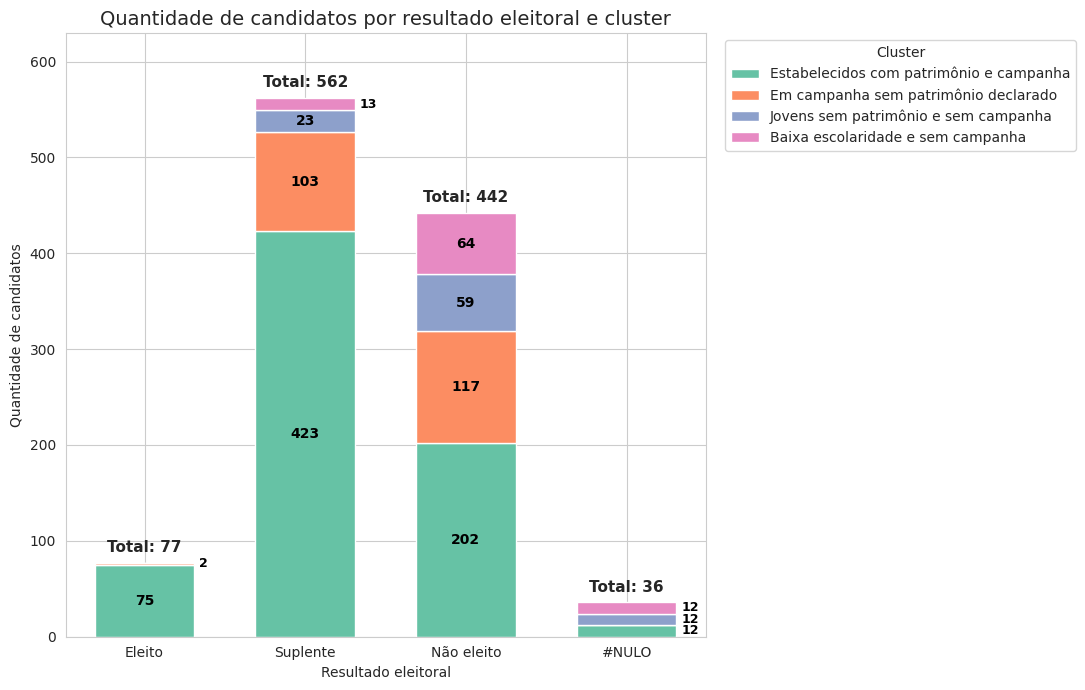

nome_cluster,Estabelecidos com patrimônio e campanha,Em campanha sem patrimônio declarado,Jovens sem patrimônio e sem campanha,Baixa escolaridade e sem campanha,Total
resultado,,,,,
Eleito,75,2,0,0,77
Suplente,423,103,23,13,562
Não eleito,202,117,59,64,442
#NULO,12,0,12,12,36
Total,712,222,94,89,1117


In [11]:
from matplotlib.colors import to_rgb


def cor_do_texto(cor):
    r, g, b = to_rgb(cor)
    return "black" if (0.299 * r + 0.587 * g + 0.114 * b) > 0.62 else "white"


def barras_empilhadas(ax, tabela, cores, formato, limite_rotulo, rotulos_x=None):
    """Linhas da tabela = barras (eixo x). Colunas = segmentos empilhados.
    Segmentos pequenos demais para caber o número recebem o rótulo ao lado da barra."""
    base = np.zeros(len(tabela))
    for seg in tabela.columns:
        valores = tabela[seg].to_numpy(dtype=float)
        ax.bar(range(len(tabela)), valores, bottom=base, color=cores[seg],
               width=0.62, edgecolor="white", label=seg)
        for i, (v, b) in enumerate(zip(valores, base)):
            if v <= 0:
                continue
            if v >= limite_rotulo:
                ax.text(i, b + v / 2, formato(v), ha="center", va="center",
                        color=cor_do_texto(cores[seg]), fontweight="bold", fontsize=10)
            else:
                ax.text(i + 0.34, b + v / 2, formato(v), ha="left", va="center",
                        color="black", fontweight="bold", fontsize=9)
        base += valores
    ax.set_xticks(range(len(tabela)))
    ax.set_xticklabels(rotulos_x if rotulos_x is not None else tabela.index)
    return base


contagem = (pd.crosstab(df_res["resultado"], df_res["nome_cluster"])
            .reindex(index=ORDEM_RESULTADO, columns=ORDEM_CLUSTER, fill_value=0))

fig, ax = plt.subplots(figsize=(11, 7))
totais = barras_empilhadas(ax, contagem, CORES_CLUSTER, lambda v: f"{int(v)}",
                           limite_rotulo=0.035 * contagem.sum(axis=1).max())
for i, t in enumerate(totais):
    ax.text(i, t + 8, f"Total: {int(t)}", ha="center", va="bottom", fontweight="bold", fontsize=11)
ax.set_ylim(0, totais.max() * 1.12)
ax.set_xlabel("Resultado eleitoral")
ax.set_ylabel("Quantidade de candidatos")
ax.set_title("Quantidade de candidatos por resultado eleitoral e cluster", fontsize=14)
ax.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

tabela_contagem = contagem.copy()
tabela_contagem["Total"] = tabela_contagem.sum(axis=1)
tabela_contagem.loc["Total"] = tabela_contagem.sum()
display(tabela_contagem)

### Lendo os dois lados: percentuais

- **Esquerda — dentro de cada cluster:** "de cada 100 candidatos do cluster, quantos tiveram cada resultado?" É o gráfico que mostra a **chance de eleição** de cada perfil.
- **Direita — dentro de cada resultado:** "de cada 100 eleitos (ou suplentes, ou não eleitos), de que cluster eles vieram?" Mostra a **composição** de cada resultado.

Atenção: o cluster A tem 64% dos candidatos, então ele naturalmente aparece muito em qualquer resultado; o que importa é se aparece **mais** ou **menos** do que esses 64% — é isso que o teste da próxima seção mede.

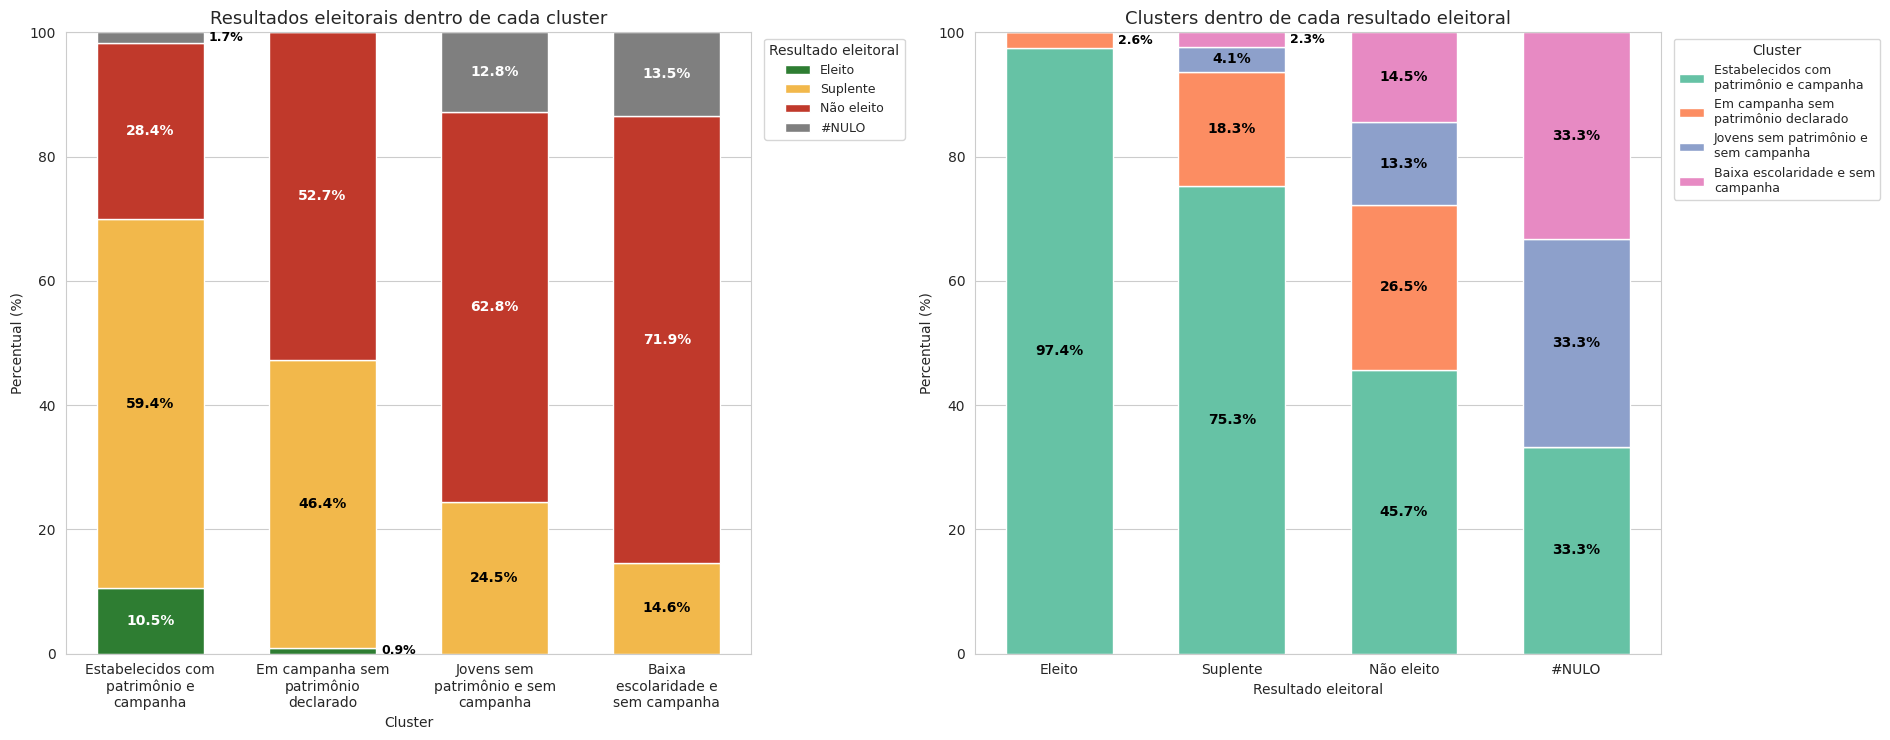

resultado,Eleito,Suplente,Não eleito,#NULO
Cluster (% da linha),,,,
Estabelecidos com patrimônio e campanha,10.5,59.4,28.4,1.7
Em campanha sem patrimônio declarado,0.9,46.4,52.7,0.0
Jovens sem patrimônio e sem campanha,0.0,24.5,62.8,12.8
Baixa escolaridade e sem campanha,0.0,14.6,71.9,13.5


In [12]:
def wrap(nome, largura=17):
    return textwrap.fill(nome, largura)


# dentro de cada cluster (cada barra soma 100%)
pct_por_cluster = (pd.crosstab(df_res["nome_cluster"], df_res["resultado"], normalize="index")
                   .mul(100).reindex(index=ORDEM_CLUSTER, columns=ORDEM_RESULTADO, fill_value=0))
# dentro de cada resultado (cada barra soma 100%)
pct_por_resultado = (pd.crosstab(df_res["resultado"], df_res["nome_cluster"], normalize="index")
                     .mul(100).reindex(index=ORDEM_RESULTADO, columns=ORDEM_CLUSTER, fill_value=0))

fig, axes = plt.subplots(1, 2, figsize=(19, 7.5))

barras_empilhadas(axes[0], pct_por_cluster, CORES_RESULTADO, lambda v: f"{v:.1f}%",
                  limite_rotulo=4, rotulos_x=[wrap(n) for n in pct_por_cluster.index])
axes[0].set_title("Resultados eleitorais dentro de cada cluster", fontsize=13)
axes[0].set_xlabel("Cluster")
axes[0].set_ylabel("Percentual (%)")
axes[0].legend(title="Resultado eleitoral", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)

barras_empilhadas(axes[1], pct_por_resultado, CORES_CLUSTER, lambda v: f"{v:.1f}%",
                  limite_rotulo=4)
axes[1].set_title("Clusters dentro de cada resultado eleitoral", fontsize=13)
axes[1].set_xlabel("Resultado eleitoral")
axes[1].set_ylabel("Percentual (%)")
axes[1].legend(title="Cluster", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9,
               labels=[wrap(n, 24) for n in ORDEM_CLUSTER])

for ax in axes:
    ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

display(pct_por_cluster.round(1).rename_axis("Cluster (% da linha)"))

## 10) Testes de associação

**Hipóteses** (para cada análise):

- H₀: o resultado eleitoral é **independente** do cluster (a proporção de eleitos é a mesma em todos os clusters).
- H₁: o resultado eleitoral **depende** do cluster.

**Ferramentas:**

- **Qui-quadrado de independência** compara a tabela observada com a que existiria se cluster e resultado fossem independentes. Só é confiável se as frequências esperadas não forem pequenas (regra usual: nenhuma abaixo de 5, ou no máximo 20% das células abaixo de 5).
- **V de Cramér** = √(χ² / (n · (min(linhas, colunas) − 1))). Vai de 0 (nenhuma associação) a 1 (associação perfeita) e **não depende do tamanho da amostra**, diferente do p-valor. Classificação usada (Cohen, ajustada pelo tamanho da tabela): desprezível, pequena, média ou grande.
- **Teste de permutação:** embaralhamos 10.000 vezes os resultados entre os candidatos (mantendo quantos são eleitos, suplentes etc.), recalculamos o χ² a cada vez e vemos em quantos embaralhamentos o χ² foi tão grande quanto o observado. Isso dá um p-valor sem depender da aproximação teórica do qui-quadrado, o que é útil quando há células com poucos casos (aqui há células com 0 ou 2 eleitos).
- **Resíduos ajustados** dizem *onde* está a associação: valores acima de +2 (ou abaixo de −2) indicam que aquela célula tem **mais** (ou **menos**) casos do que o esperado se não houvesse associação.

In [13]:
def classificar_v(v, gl_min):
    """Cohen (1988): limiares de 0,10 / 0,30 / 0,50 divididos por √(min(linhas, colunas) − 1)."""
    f = np.sqrt(gl_min)
    if v < 0.10 / f:
        return "desprezível"
    if v < 0.30 / f:
        return "pequena"
    if v < 0.50 / f:
        return "média"
    return "grande"


def teste_associacao(dados, col_cluster, col_resultado, n_perm=10_000, semente=SEMENTE):
    d = dados[[col_cluster, col_resultado]].dropna()
    tabela = pd.crosstab(d[col_cluster], d[col_resultado])
    n = int(tabela.values.sum())
    nl, nc = tabela.shape
    gl_min = min(nl, nc) - 1

    chi2, p, gl, esp = chi2_contingency(tabela, correction=False)
    v = np.sqrt(chi2 / (n * gl_min))

    obs = tabela.to_numpy(dtype=float)
    prop_lin = obs.sum(axis=1, keepdims=True) / n
    prop_col = obs.sum(axis=0, keepdims=True) / n
    residuos = (obs - esp) / np.sqrt(esp * (1 - prop_lin) * (1 - prop_col))

    # Permutação: embaralha o resultado entre os candidatos; as margens (tamanho dos clusters e
    # total por resultado) ficam fixas, então a tabela de esperados é a mesma em todas as rodadas.
    cod_cl = pd.Categorical(d[col_cluster], categories=tabela.index).codes
    cod_rs = pd.Categorical(d[col_resultado], categories=tabela.columns).codes

    def chi2_de(cod_r):
        o = np.bincount(cod_cl * nc + cod_r, minlength=nl * nc).reshape(nl, nc)
        return ((o - esp) ** 2 / esp).sum()

    rng = np.random.default_rng(semente)
    chi2_obs = chi2_de(cod_rs)
    chi2_perm = np.array([chi2_de(rng.permutation(cod_rs)) for _ in range(n_perm)])
    p_perm = (1 + (chi2_perm >= chi2_obs - 1e-9).sum()) / (n_perm + 1)

    return {
        "n": n, "tabela": tabela, "chi2": chi2, "gl": gl, "p": p, "v": v, "gl_min": gl_min,
        "classe_v": classificar_v(v, gl_min),
        "esperado": pd.DataFrame(esp, index=tabela.index, columns=tabela.columns),
        "residuos": pd.DataFrame(residuos, index=tabela.index, columns=tabela.columns),
        "pct_esp_baixo": (esp < 5).mean() * 100, "min_esp": esp.min(),
        "chi2_perm": chi2_perm, "p_perm": p_perm, "n_perm": n_perm,
    }


def fmt_milhar(n):
    return f"{n:,}".replace(",", ".")


def texto_p_perm(r):
    """p = (1 + nº de permutações com χ² >= observado) / (1 + nº de permutações). Nunca é zero."""
    if r["p_perm"] <= 1.5 / (r["n_perm"] + 1):
        return f"< {1 / r['n_perm']:.4f} (nenhum embaralhamento chegou ao χ² observado)"
    return f"{r['p_perm']:.4f}"


def mostrar_teste(r, titulo):
    print(titulo)
    print("=" * len(titulo))
    print(f"Candidatos na análise: {r['n']}")
    print(f"Qui-quadrado: {r['chi2']:.2f}  (gl = {r['gl']})")
    print(f"p-valor (qui-quadrado): {r['p']:.2e}")
    print(f"V de Cramér: {r['v']:.3f}  -> associação {r['classe_v']}")
    print(f"Células com frequência esperada abaixo de 5: {r['pct_esp_baixo']:.1f}%  (menor esperado = {r['min_esp']:.2f})")
    if r["pct_esp_baixo"] > 20 or r["min_esp"] < 1:
        print("Há frequências esperadas pequenas: o p-valor da permutação é o mais confiável.")
    else:
        print("As frequências esperadas são adequadas para o qui-quadrado; a permutação serve de confirmação.")
    print(f"p-valor (permutação, {fmt_milhar(r['n_perm'])} embaralhamentos): {texto_p_perm(r)}")
    print(f"Maior χ² obtido ao acaso nas permutações: {r['chi2_perm'].max():.2f} (observado: {r['chi2']:.2f})")
    print("\nTabela observada:")
    display(r["tabela"])
    print("Frequências esperadas se cluster e resultado fossem independentes:")
    display(r["esperado"].round(1))
    print("Resíduos ajustados (|valor| > 2 = diferença relevante):")
    display(r["residuos"].round(2))


teste_bin = teste_associacao(df_res, "nome_cluster", "resultado_bin")
teste_3cat = teste_associacao(df_res, "nome_cluster", "resultado_3cat")

mostrar_teste(teste_bin, "ANÁLISE PRINCIPAL — Eleito × Não eleito (suplentes + não eleitos)")

ANÁLISE PRINCIPAL — Eleito × Não eleito (suplentes + não eleitos)
Candidatos na análise: 1081
Qui-quadrado: 38.83  (gl = 3)
p-valor (qui-quadrado): 1.88e-08
V de Cramér: 0.190  -> associação pequena
Células com frequência esperada abaixo de 5: 0.0%  (menor esperado = 5.48)
As frequências esperadas são adequadas para o qui-quadrado; a permutação serve de confirmação.
p-valor (permutação, 10.000 embaralhamentos): < 0.0001 (nenhum embaralhamento chegou ao χ² observado)
Maior χ² obtido ao acaso nas permutações: 23.18 (observado: 38.83)

Tabela observada:


resultado_bin,Eleito,Não eleito
nome_cluster,,
Baixa escolaridade e sem campanha,0,77
Em campanha sem patrimônio declarado,2,220
Estabelecidos com patrimônio e campanha,75,625
Jovens sem patrimônio e sem campanha,0,82


Frequências esperadas se cluster e resultado fossem independentes:


resultado_bin,Eleito,Não eleito
nome_cluster,,
Baixa escolaridade e sem campanha,5.5,71.5
Em campanha sem patrimônio declarado,15.8,206.2
Estabelecidos com patrimônio e campanha,49.9,650.1
Jovens sem patrimônio e sem campanha,5.8,76.2


Resíduos ajustados (|valor| > 2 = diferença relevante):


resultado_bin,Eleito,Não eleito
nome_cluster,,
Baixa escolaridade e sem campanha,-2.52,2.52
Em campanha sem patrimônio declarado,-4.04,4.04
Estabelecidos com patrimônio e campanha,6.22,-6.22
Jovens sem patrimônio e sem campanha,-2.61,2.61


In [14]:
mostrar_teste(teste_3cat, "ANÁLISE COMPLEMENTAR — Eleito × Suplente × Não eleito")

ANÁLISE COMPLEMENTAR — Eleito × Suplente × Não eleito
Candidatos na análise: 1081
Qui-quadrado: 159.58  (gl = 6)
p-valor (qui-quadrado): 7.28e-32
V de Cramér: 0.272  -> associação média
Células com frequência esperada abaixo de 5: 0.0%  (menor esperado = 5.48)
As frequências esperadas são adequadas para o qui-quadrado; a permutação serve de confirmação.
p-valor (permutação, 10.000 embaralhamentos): < 0.0001 (nenhum embaralhamento chegou ao χ² observado)
Maior χ² obtido ao acaso nas permutações: 27.83 (observado: 159.58)

Tabela observada:


resultado_3cat,Eleito,Não eleito,Suplente
nome_cluster,,,
Baixa escolaridade e sem campanha,0,64,13
Em campanha sem patrimônio declarado,2,117,103
Estabelecidos com patrimônio e campanha,75,202,423
Jovens sem patrimônio e sem campanha,0,59,23


Frequências esperadas se cluster e resultado fossem independentes:


resultado_3cat,Eleito,Não eleito,Suplente
nome_cluster,,,
Baixa escolaridade e sem campanha,5.5,31.5,40.0
Em campanha sem patrimônio declarado,15.8,90.8,115.4
Estabelecidos com patrimônio e campanha,49.9,286.2,363.9
Jovens sem patrimônio e sem campanha,5.8,33.5,42.6


Resíduos ajustados (|valor| > 2 = diferença relevante):


resultado_3cat,Eleito,Não eleito,Suplente
nome_cluster,,,
Baixa escolaridade e sem campanha,-2.52,7.82,-6.40
Em campanha sem patrimônio declarado,-4.04,4.02,-1.87
Estabelecidos com patrimônio e campanha,6.22,-10.91,7.53
Jovens sem patrimônio e sem campanha,-2.61,5.95,-4.51


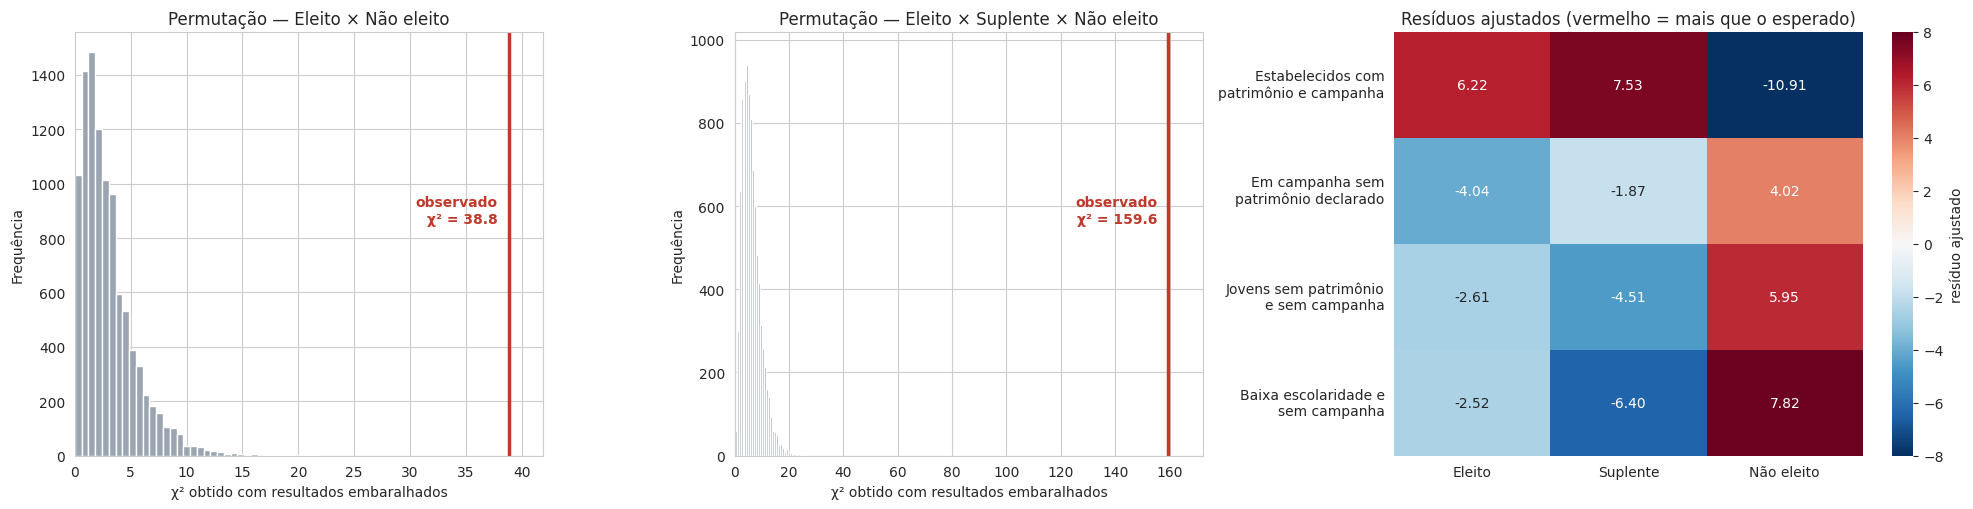

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5.2), gridspec_kw={"width_ratios": [1, 1, 1.25]})

for ax, r, titulo in [(axes[0], teste_bin, "Eleito × Não eleito"), (axes[1], teste_3cat, "Eleito × Suplente × Não eleito")]:
    ax.hist(r["chi2_perm"], bins=np.linspace(0, r["chi2_perm"].max() * 1.02, 40), color="#9aa5b1", edgecolor="white")
    ax.axvline(r["chi2"], color="#c0392b", linewidth=2.5)
    ax.annotate(f"observado\nχ² = {r['chi2']:.1f}", xy=(r["chi2"], ax.get_ylim()[1] * 0.55),
                xytext=(-8, 0), textcoords="offset points", ha="right", color="#c0392b", fontweight="bold")
    ax.set_title(f"Permutação — {titulo}")
    ax.set_xlabel("χ² obtido com resultados embaralhados")
    ax.set_ylabel("Frequência")
    ax.set_xlim(0, max(r["chi2"], r["chi2_perm"].max()) * 1.08)

res3 = teste_3cat["residuos"].reindex(index=ORDEM_CLUSTER, columns=["Eleito", "Suplente", "Não eleito"])
sns.heatmap(res3, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-8, vmax=8, ax=axes[2],
            yticklabels=[wrap(n, 22) for n in res3.index], cbar_kws={"label": "resíduo ajustado"})
axes[2].set_title("Resíduos ajustados (vermelho = mais que o esperado)")
axes[2].set_xlabel("")
axes[2].set_ylabel("")
axes[2].tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()

## 11) Checagens extras

**(a) Sensibilidade ao `#NULO`.** Se os 36 candidatos sem resultado fossem, na verdade, "não eleitos", a conclusão muda?

**(b) Possível fator de confusão: quem já é deputado.** A base não tem uma coluna de reeleição, mas a ocupação declarada (`DS_OCUPACAO = "DEPUTADO"`) é um indicativo razoável de quem já exerce mandato. Candidatos assim tendem a ter patrimônio, estrutura de campanha e partido fortes — exatamente o que define o cluster A — e também tendem a se reeleger. Se isso for o caso, parte da associação *cluster × resultado* é, na verdade, *carreira política × resultado*.

In [16]:
# (a) #NULO tratado como "Não eleito"
df_sens = df_res.copy()
df_sens["resultado_sens"] = np.where(df_sens["resultado"] == "Eleito", "Eleito", "Não eleito")
t_sens = pd.crosstab(df_sens["nome_cluster"], df_sens["resultado_sens"])
chi2_s, p_s, gl_s, _ = chi2_contingency(t_sens, correction=False)
v_s = np.sqrt(chi2_s / t_sens.values.sum())
print(f"(a) Com os #NULO contados como 'Não eleito' (n = {t_sens.values.sum()}): "
      f"χ² = {chi2_s:.2f}, gl = {gl_s}, p = {p_s:.2e}, V de Cramér = {v_s:.3f}")

# (b) quem declara ocupação DEPUTADO
df_res["ocupacao_deputado"] = np.where(df_res["DS_OCUPACAO"].eq("DEPUTADO"), "Declara 'DEPUTADO'", "Outra ocupação")
com_resultado = df_res[df_res["resultado"] != "#NULO"].copy()
com_resultado["eleito"] = com_resultado["resultado"].eq("Eleito")

print("\n(b) Taxa de eleição por cluster e ocupação declarada:")
tab_conf = (com_resultado.groupby(["cluster_bisecting", "ocupacao_deputado"])["eleito"]
            .agg(eleitos="sum", candidatos="count"))
tab_conf["taxa_eleicao_%"] = (tab_conf["eleitos"] / tab_conf["candidatos"] * 100).round(1)
display(tab_conf)

nao_dep = com_resultado[com_resultado["ocupacao_deputado"] == "Outra ocupação"]
r_nd = teste_associacao(nao_dep, "nome_cluster", "resultado_bin")
print(f"\n(b) Só entre quem NÃO declara ocupação DEPUTADO (n = {r_nd['n']}, "
      f"{int(r_nd['tabela']['Eleito'].sum())} eleitos): χ² = {r_nd['chi2']:.2f}, gl = {r_nd['gl']}, "
      f"V de Cramér = {r_nd['v']:.3f} ({r_nd['classe_v']}), p do qui-quadrado = {r_nd['p']:.2e}, "
      f"p da permutação {texto_p_perm(r_nd)}")
print(f"    Células com esperado < 5: {r_nd['pct_esp_baixo']:.1f}% (menor esperado = {r_nd['min_esp']:.2f}) "
      "-> aqui vale confiar na permutação.")
eleitos = com_resultado[com_resultado["eleito"]]
n_dep = int((eleitos["DS_OCUPACAO"] == "DEPUTADO").sum())
print(f"Entre os {len(eleitos)} eleitos, {n_dep} declararam a ocupação DEPUTADO.")

(a) Com os #NULO contados como 'Não eleito' (n = 1117): χ² = 40.67, gl = 3, p = 7.68e-09, V de Cramér = 0.191

(b) Taxa de eleição por cluster e ocupação declarada:


eleitos  candidatos  taxa_eleicao_%
cluster_bisecting ocupacao_deputado                                      
A                 Declara 'DEPUTADO'       35          53            66.0
                  Outra ocupação           40         647             6.2
B                 Declara 'DEPUTADO'        2           2           100.0
                  Outra ocupação            0         220             0.0
C                 Outra ocupação            0          82             0.0
D                 Outra ocupação            0          77             0.0


(b) Só entre quem NÃO declara ocupação DEPUTADO (n = 1026, 40 eleitos): χ² = 24.38, gl = 3, V de Cramér = 0.154 (pequena), p do qui-quadrado = 2.08e-05, p da permutação 0.0003
    Células com esperado < 5: 25.0% (menor esperado = 3.00) -> aqui vale confiar na permutação.
Entre os 77 eleitos, 37 declararam a ocupação DEPUTADO.


## 12) Conclusão

### Resposta direta

**Sim: há associação estatisticamente significativa entre o cluster do candidato e o resultado nas urnas.** Ela é **pequena** pela classificação usual do V de Cramér na análise binária, mas **concentrada e nítida na prática**: praticamente só quem está no cluster A se elegeu. **Isso não demonstra causalidade.**

### Os números

| | Eleito × Não eleito (principal) | Eleito × Suplente × Não eleito (complementar) |
|---|---|---|
| Candidatos na análise | 1.081 | 1.081 |
| χ² (gl) | 38,83 (3) | 159,58 (6) |
| p-valor do qui-quadrado | 1,9 × 10⁻⁸ | 7,3 × 10⁻³² |
| p-valor da permutação (10.000 embaralhamentos) | < 0,0001 | < 0,0001 |
| **V de Cramér** | **0,190 (pequena)** | **0,272 (média)** |
| Frequências esperadas < 5 | 0% (menor = 5,5) | 0% (menor = 5,5) |

Como nenhuma célula tem frequência esperada abaixo de 5, o qui-quadrado é confiável aqui, e o teste de permutação **confirma** o resultado: em 10.000 embaralhamentos do resultado, o maior χ² obtido ao acaso foi 23,2 (análise binária) e 27,8 (3 categorias), muito abaixo dos valores observados (38,8 e 159,6).

### Onde está a associação (resíduos ajustados)

| Cluster | Eleitos (de quem tem resultado) | Resíduo — Eleito |
|---|---|---|
| **A — Estabelecidos com patrimônio e campanha** | **75 de 700 (10,7%)** | **+6,22** (muito acima do esperado) |
| B — Em campanha sem patrimônio declarado | 2 de 222 (0,9%) | −4,04 |
| C — Jovens sem patrimônio e sem campanha | 0 de 82 | −2,61 |
| D — Baixa escolaridade e sem campanha | 0 de 77 | −2,52 |

- Dos **77 eleitos, 75 (97,4%) são do cluster A**, que reúne cerca de 65% dos candidatos com resultado. Os outros 2 são do cluster B; **nenhum** eleito veio dos clusters C ou D.
- Na análise com 3 categorias, o cluster A também tem **mais suplentes** que o esperado (+7,53) e **menos não eleitos** (−10,91). Os clusters C e D fazem o inverso: muitos não eleitos (+5,95 e +7,82) e poucos suplentes (−4,51 e −6,40). Ou seja, o gradiente é de "viabilidade eleitoral": A é competitivo, B fica no meio, C e D ficam de fora.

### Por que o V de Cramér é "só" 0,19 se a diferença é tão grande?

O desfecho é raro (7% de eleitos), e com desfecho raro o V de Cramér tende a ficar baixo mesmo quando o contraste prático é grande: 10,7% de eleição no cluster A contra 0% a 0,9% nos demais. Por isso reportamos o V junto com as taxas e os resíduos, e não sozinho.

### Checagens de robustez

- **#NULO como "não eleito"** (n = 1.117): χ² = 40,67; p = 7,7 × 10⁻⁹; V = 0,191. A conclusão não muda.
- **Quem já é deputado.** Dos 77 eleitos, **37 declararam a ocupação DEPUTADO**, e esse grupo se elege muito mais (no cluster A: 66% contra 6,2% dos demais). Isso é um fator de confusão provável: o cluster A concentra quem faz carreira política. Mesmo **retirando esses candidatos**, a associação continua (n = 1.026; χ² = 24,38; **V = 0,154**; p da permutação = 0,0003): o cluster A elegeu 40 de 647 (6,2%), e os clusters B, C e D elegeram 0 de 379. Ou seja, a associação **não se resume** a "deputado em exercício", mas **diminui** quando esse grupo sai da conta.

### Como interpretar (e como não interpretar)

- **Associação não é causalidade.** Pertencer ao cluster A não *causa* a eleição. Os clusters descrevem perfis (idade, escolaridade, patrimônio e gasto de campanha) que andam junto com outros fatores que não medimos: partido e acesso ao fundo eleitoral, reeleição, visibilidade, base eleitoral, tempo de TV.
- **Causalidade reversa é plausível.** O gasto de campanha é uma das quatro variáveis que definem os clusters, e os partidos tendem a concentrar dinheiro em quem já tem chance de ganhar. Assim, "gastar muito" pode ser **consequência** da viabilidade, e não causa dela.
- **Limitações dos dados.** O gasto de campanha vem de um extrato parcial da prestação de contas; 36 candidatos (3%) estão sem resultado (`#NULO`) e ficaram fora dos testes; 1 candidato do arquivo do TSE não está nos clusters e foi excluído; e "suplente" não é um resultado homogêneo (depende da votação do partido ou coligação).
- **O que o resultado diz sobre os clusters.** Eles **não foram construídos para prever eleição** (o resultado nem entrou na clusterização), e mesmo assim separam bem quem tem chance de quem não tem. É um indício de que os perfis capturados têm **relevância eleitoral**, o que reforça a utilidade dos clusters como descrição dos candidatos, sem torná-los um modelo preditivo.
